<a href="https://colab.research.google.com/github/AvisarBhandari/Ml/blob/main/01_pytorch_Binary_and_Multiclass_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import make_circles

# Sampel size
sample_size=1000

# data set
X,Y=make_circles(n_samples=sample_size,
                 noise=0.03,
                 random_state=42)


In [2]:
len(X) ,len(Y)

(1000, 1000)

In [3]:
print(f"First 5 number of X {X[:5]}")
print(f"First 5 number of y {Y[:5]}")

First 5 number of X [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 number of y [1 1 1 1 0]


In [4]:
# Data frame
import pandas as pd
circles=pd.DataFrame({"X1":X[:,0],
                      "X2":X[:,1],
                      "label":Y})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


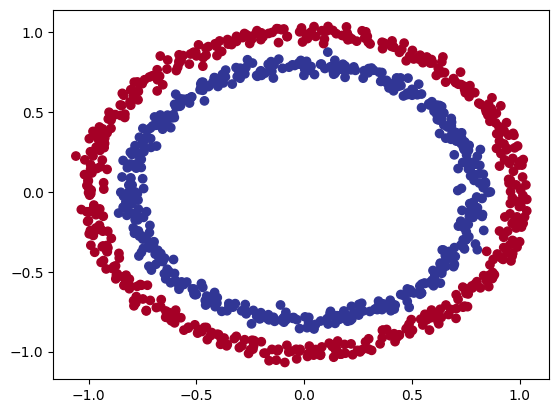

In [5]:
import matplotlib.pyplot as plt
plt.scatter(x=X[:,0],
            y=X[:,1],
            c=Y,
            cmap=plt.cm.RdYlBu)

Toy data set 1☝️

In [6]:
X.shape , Y.shape

((1000, 2), (1000,))

In [7]:
import torch
torch.__version__

'2.10.0+cu128'

In [8]:
type(X) ,X.dtype

(numpy.ndarray, dtype('float64'))

In [9]:
# numpy to tensors
x= torch.from_numpy(X).type(torch.float);
y= torch.from_numpy(Y).type(torch.float);

x[:5],y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [10]:
type(x), x.dtype,type(y),y.dtype

(torch.Tensor, torch.float32, torch.Tensor, torch.float32)

In [11]:
# splite data
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,
                                               y,
                                               test_size=0.2,
                                               random_state=42)

In [12]:
len(x_train),len(x_test),len(y_train),len(y_test)

(800, 200, 800, 200)

In [13]:
import torch
from torch import nn

# device agnostic
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [14]:
# model
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2,out_features=8)
    self.layer_2 =nn.Linear(in_features=8,out_features=1)
  def forward(self,x):
    return self.layer_2(self.layer_1(x))


model_0=CircleModelV1().to(device)
model_0

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=8, bias=True)
  (layer_2): Linear(in_features=8, out_features=1, bias=True)
)

In [15]:
next(model_0.parameters()).device

device(type='cuda', index=0)

In [16]:
with torch.inference_mode():
  untrain_preds=model_0(x_test.to(device))
print(f"Length of predictions: {len(untrain_preds)}, Shape: {untrain_preds.shape}")
print(f"Length of test sample: {len(x_test)}, shape: {x_test.shape}")
print(f"First 10 predictions: {torch.round(untrain_preds[:10])}")
print(f"First 10 label: {y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test sample: 200, shape: torch.Size([200, 2])
First 10 predictions: tensor([[0.],
        [0.],
        [-0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [-0.],
        [0.]], device='cuda:0')
First 10 label: tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


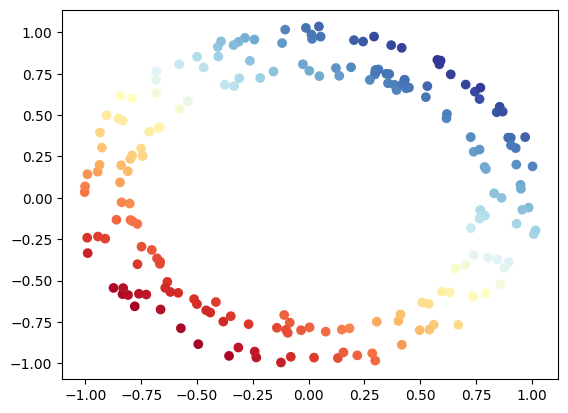

In [17]:
plot_X= untrain_preds.cpu()
plt.scatter(x=x_test[:, 0],
            y=x_test[:, 1],
            c=plot_X.squeeze(),
            cmap=plt.cm.RdYlBu)

In [18]:
loss_fn = nn.BCEWithLogitsLoss() # sigmoid activation built-in un-like in 'BCELoss()'
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)

In [19]:
def accuracy_fn(y_true,y_pred):
  correct=torch.eq(y_true,y_pred).sum().item()
  acc=correct/len(y_pred)*100
  return acc


In [20]:
model_0.eval()
with torch.inference_mode():
  y_logits = model_0(x_test.to(device))[:5]
y_logits

tensor([[ 0.3149],
        [ 0.4663],
        [-0.0160],
        [ 0.4084],
        [ 0.0886]], device='cuda:0')

In [21]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [22]:
y_pred_probs=torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.5781],
        [0.6145],
        [0.4960],
        [0.6007],
        [0.5221]], device='cuda:0')

In [23]:
y_pred=torch.round(y_pred_probs)

y_pred_lable=torch.round(torch.sigmoid(model_0(x_test.to(device))[:5]))

print(torch.eq(y_pred.squeeze(),y_pred_lable.squeeze()))

tensor([True, True, True, True, True], device='cuda:0')


In [24]:
torch.cuda.manual_seed(42)
torch.manual_seed(42)

epochs= 100

# pute data to the target device
X_train , X_test = x_train.to(device), x_test.to(device)
Y_train , Y_test = y_train.to(device), y_test.to(device)

# build the traning loop
for epoch in range(epochs):
  model_0.train()

  # forward pass
  y_logits = model_0(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  # calculate the loss/accuracy
  loss = loss_fn(y_logits # nn.BCEWithLogitsLoss expect raw logits as input
                 ,Y_train)
  acc = accuracy_fn(y_true=Y_train,y_pred=y_pred)

  # optimize zero grad
  optimizer.zero_grad()

  # loss backward
  loss.backward()

  # optimizer step (gradient decent)
  optimizer.step()

  # testing
  model_0.eval()
  with torch.inference_mode():
    # forward pass
    test_logits= model_0(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    # accuracy
    test_acc=accuracy_fn(y_true=Y_test,y_pred=test_pred)
    test_loss=loss_fn(test_logits,Y_test)
  if epoch % 10 == 0:
      print(f"Epoch:{epoch} | Loss: {loss:.5f} | Acc:{acc:.2f}% | Test_Loss: {test_loss:.5f} | Test_Acc: {test_acc:.2f}%")

Epoch:0 | Loss: 0.70186 | Acc:54.62% | Test_Loss: 0.71202 | Test_Acc: 47.50%
Epoch:10 | Loss: 0.69707 | Acc:52.00% | Test_Loss: 0.70622 | Test_Acc: 47.00%
Epoch:20 | Loss: 0.69561 | Acc:52.00% | Test_Loss: 0.70373 | Test_Acc: 48.50%
Epoch:30 | Loss: 0.69490 | Acc:51.62% | Test_Loss: 0.70216 | Test_Acc: 46.50%
Epoch:40 | Loss: 0.69443 | Acc:51.25% | Test_Loss: 0.70097 | Test_Acc: 46.00%
Epoch:50 | Loss: 0.69409 | Acc:51.38% | Test_Loss: 0.70002 | Test_Acc: 45.50%
Epoch:60 | Loss: 0.69384 | Acc:51.25% | Test_Loss: 0.69923 | Test_Acc: 45.00%
Epoch:70 | Loss: 0.69364 | Acc:51.12% | Test_Loss: 0.69858 | Test_Acc: 45.00%
Epoch:80 | Loss: 0.69349 | Acc:51.12% | Test_Loss: 0.69803 | Test_Acc: 45.00%
Epoch:90 | Loss: 0.69338 | Acc:51.12% | Test_Loss: 0.69757 | Test_Acc: 45.00%


In [25]:
import requests
from pathlib import Path

if Path("helper_function.py").is_file():
  print("helper_function.py already exists")
else:
  print("Downloading helper_function.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_function.py","wb") as f:
    f.write(request.content)
from helper_function import plot_predictions, plot_decision_boundary

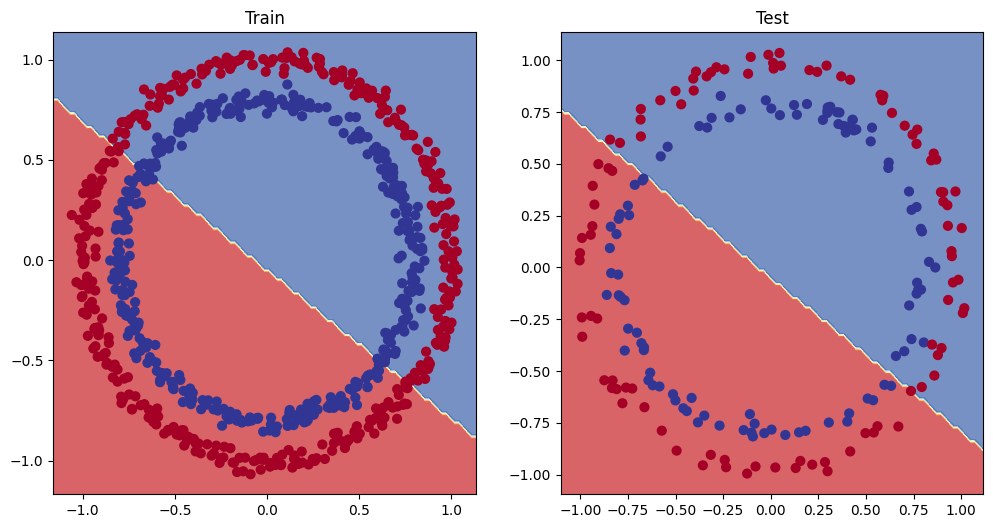

In [26]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0,X_train,Y_train)

plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0,X_test,Y_test)


In [27]:
class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2,out_features=10)
    self.layer_2 =nn.Linear(in_features=10,out_features=10)

    self.layer_3 = nn.Linear(in_features=10,out_features=1)
  def forward(self,x):
    return self.layer_3(self.layer_2(self.layer_1(x)))


model_1=CircleModelV2().to(device)
model_1

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [28]:
loss_fn = nn.BCEWithLogitsLoss() # sigmoid activation built-in un-like in 'BCELoss()'
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.01)

In [29]:
torch.cuda.manual_seed(42)
torch.manual_seed(42)

epochs= 1000

# pute data to the target device
X_train , X_test = x_train.to(device), x_test.to(device)
Y_train , Y_test = y_train.to(device), y_test.to(device)

# build the traning loop
for epoch in range(epochs):
  model_1.train()

  # forward pass
  y_logits = model_1(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  # calculate the loss/accuracy
  loss = loss_fn(y_logits # nn.BCEWithLogitsLoss expect raw logits as input
                 ,Y_train)
  acc = accuracy_fn(y_true=Y_train,y_pred=y_pred)

  # optimize zero grad
  optimizer.zero_grad()

  # loss backward
  loss.backward()

  # optimizer step (gradient decent)
  optimizer.step()

  # testing
  model_1.eval()
  with torch.inference_mode():
    # forward pass
    test_logits= model_1(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    # accuracy
    test_acc=accuracy_fn(y_true=Y_test,y_pred=test_pred)
    test_loss=loss_fn(test_logits,Y_test)
  if epoch % 100 == 0:
      print(f"Epoch:{epoch} | Loss: {loss:.5f} | Acc:{acc:.2f}% | Test_Loss: {test_loss:.5f} | Test_Acc: {test_acc:.2f}%")

Epoch:0 | Loss: 0.69396 | Acc:50.88% | Test_Loss: 0.69261 | Test_Acc: 51.00%
Epoch:100 | Loss: 0.69369 | Acc:50.25% | Test_Loss: 0.69269 | Test_Acc: 50.00%
Epoch:200 | Loss: 0.69351 | Acc:50.12% | Test_Loss: 0.69282 | Test_Acc: 49.50%
Epoch:300 | Loss: 0.69339 | Acc:50.50% | Test_Loss: 0.69295 | Test_Acc: 49.00%
Epoch:400 | Loss: 0.69329 | Acc:50.38% | Test_Loss: 0.69309 | Test_Acc: 48.50%
Epoch:500 | Loss: 0.69322 | Acc:49.88% | Test_Loss: 0.69322 | Test_Acc: 49.50%
Epoch:600 | Loss: 0.69317 | Acc:49.50% | Test_Loss: 0.69335 | Test_Acc: 53.00%
Epoch:700 | Loss: 0.69313 | Acc:49.38% | Test_Loss: 0.69347 | Test_Acc: 50.50%
Epoch:800 | Loss: 0.69309 | Acc:50.00% | Test_Loss: 0.69358 | Test_Acc: 51.00%
Epoch:900 | Loss: 0.69307 | Acc:50.62% | Test_Loss: 0.69368 | Test_Acc: 47.50%


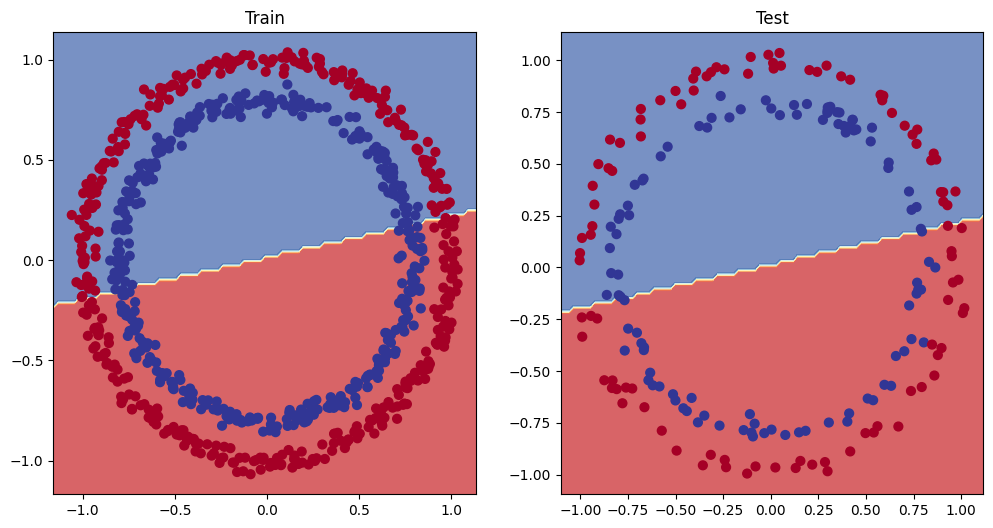

In [30]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1,X_train,Y_train)

plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_1,X_test,Y_test)


In [31]:


# Create some data (same as notebook 01)
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

# Create data
X_regression = torch.arange(start, end, step).unsqueeze(dim=1)
y_regression = weight * X_regression + bias # Linear regression formula (without epsilon)

# Check the data
print(len(X_regression))
X_regression[:5], y_regression[:5]



100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [32]:

# Create train and test splits
train_split = int(0.8 * len(X_regression))
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]

# Check the lengths of each
len(X_train_regression), len(X_test_regression), len(y_train_regression), len(y_test_regression)

(80, 20, 80, 20)

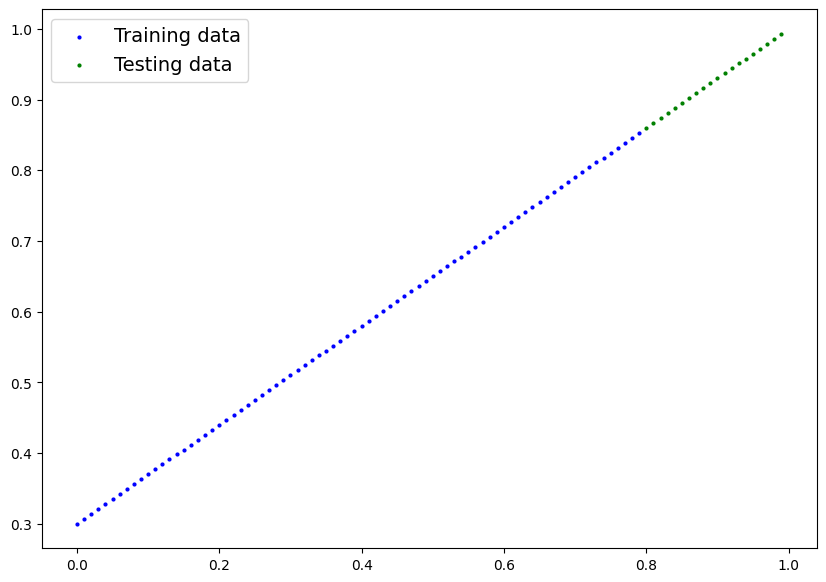

In [33]:
plot_predictions(train_data=X_train_regression,
                 train_labels=y_train_regression,
                 test_data=X_test_regression,
                 test_labels=y_test_regression);

In [34]:
# Same architecture as model_1 (but using nn.Sequential())
model_2 = nn.Sequential(
    nn.Linear(in_features=1, out_features=10),
    nn.Linear(in_features=10, out_features=10),
    nn.Linear(in_features=10, out_features=1)
).to(device)

model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [35]:
# Loss and optimizer
loss_fn = nn.L1Loss() # MAE loss with regression data
optimizer = torch.optim.SGD(params=model_2.parameters(),
                            lr=0.01)

In [36]:
# Train the model
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set the number of epochs
epochs = 1000

# Put the data on the target device
X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

# Training
for epoch in range(epochs):
  y_pred = model_2(X_train_regression)
  loss = loss_fn(y_pred, y_train_regression)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  # Testing
  model_2.eval()
  with torch.inference_mode():
    test_pred = model_2(X_test_regression)
    test_loss = loss_fn(test_pred, y_test_regression)

  # Print out what's happenin'
  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Test loss: {test_loss:.5f}")

Epoch: 0 | Loss: 0.75986 | Test loss: 0.91103
Epoch: 100 | Loss: 0.02858 | Test loss: 0.00081
Epoch: 200 | Loss: 0.02533 | Test loss: 0.00209
Epoch: 300 | Loss: 0.02137 | Test loss: 0.00305
Epoch: 400 | Loss: 0.01964 | Test loss: 0.00341
Epoch: 500 | Loss: 0.01940 | Test loss: 0.00387
Epoch: 600 | Loss: 0.01903 | Test loss: 0.00379
Epoch: 700 | Loss: 0.01878 | Test loss: 0.00381
Epoch: 800 | Loss: 0.01840 | Test loss: 0.00329
Epoch: 900 | Loss: 0.01798 | Test loss: 0.00360


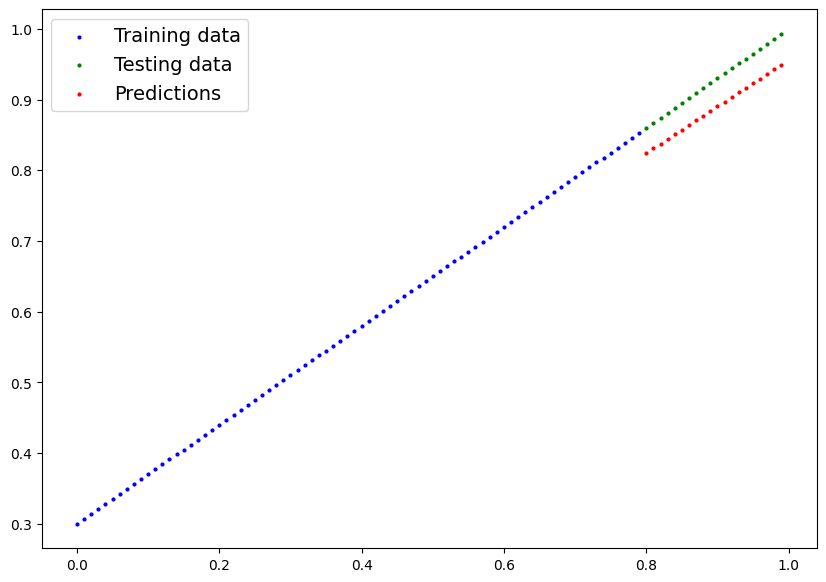

In [37]:
# Turn on evaluation mode
model_2.eval()

# Make predictions (inference)
with torch.inference_mode():
  y_preds = model_2(X_test_regression)

# Plot data and predictions
plot_predictions(train_data=X_train_regression.cpu(),
                 train_labels=y_train_regression.cpu(),
                 test_data=X_test_regression.cpu(),
                 test_labels=y_test_regression.cpu(),
                 predictions=y_preds.cpu());

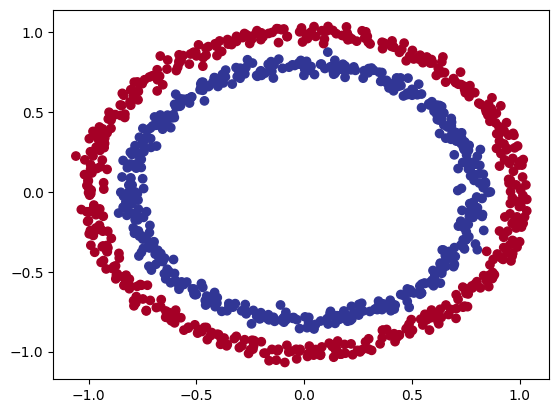

In [38]:

# Make and plot data
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu);

# **Non-Linear**

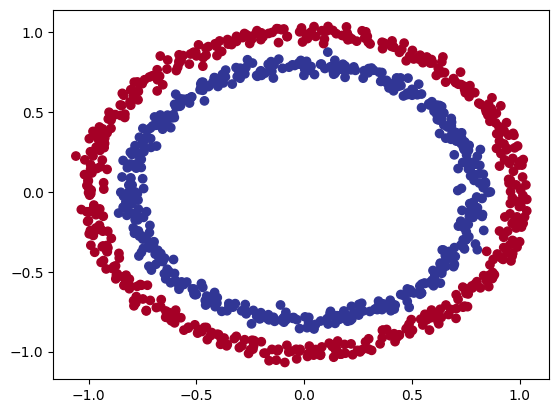

In [71]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

n_samples= 1000
X, Y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)
plt.scatter(X[:,0],X[:,1],c=Y,cmap=plt.cm.RdYlBu)

In [72]:
import torch
from sklearn.model_selection import train_test_split

X = torch.from_numpy(X).type(torch.float)
Y = torch.from_numpy(Y).type(torch.float)

# train test split

X_train, X_test, Y_train, Y_test = train_test_split(X,
                                               Y,
                                               test_size=0.2,
                                               random_state=42)
X_train[:5], Y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

In [73]:
len(X_train), len(X_test), len(Y_train), len(Y_test)

(800, 200, 800, 200)

In [74]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [75]:
from torch import nn
class CircleModelV3(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2 , out_features=10)
    self.layer_2 = nn.Linear(in_features=10,out_features=10)
    self.layer_3 = nn.Linear(in_features=10,out_features=1)
    self.relu= nn.ReLU()
  def forward(self,x):
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_3=CircleModelV3().to(device)
model_3

CircleModelV3(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [76]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_3.parameters(),
                            lr=0.1)

In [77]:
# Random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Put all data on target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Loop through data
epochs = 5000

for epoch in range(epochs):
  ### Training
  model_3.train()

  # 1. Forward pass
  y_logits = model_3(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits)) # logits -> prediction probabilities -> prediction labels

  # 2. Calculate the loss
  loss = loss_fn(y_logits, y_train) # BCEWithLogitsLoss (takes in logits as first input)
  acc = accuracy_fn(y_true=y_train,
                    y_pred=y_pred)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backward
  loss.backward()

  # 5. Step the optimizer
  optimizer.step()

  ### Testing
  model_3.eval()
  with torch.inference_mode():
    test_logits = model_3(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_true=y_test,
                           y_pred=test_pred)

  # Print out what's this happenin'
  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.4f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.6929, Acc: 50.00% | Test Loss: 0.6932, Test Acc: 50.00%
Epoch: 100 | Loss: 0.6912, Acc: 52.88% | Test Loss: 0.6910, Test Acc: 52.50%
Epoch: 200 | Loss: 0.6898, Acc: 53.37% | Test Loss: 0.6894, Test Acc: 55.00%
Epoch: 300 | Loss: 0.6879, Acc: 53.00% | Test Loss: 0.6872, Test Acc: 56.00%
Epoch: 400 | Loss: 0.6852, Acc: 52.75% | Test Loss: 0.6841, Test Acc: 56.50%
Epoch: 500 | Loss: 0.6810, Acc: 52.75% | Test Loss: 0.6794, Test Acc: 56.50%
Epoch: 600 | Loss: 0.6751, Acc: 54.50% | Test Loss: 0.6729, Test Acc: 56.00%
Epoch: 700 | Loss: 0.6666, Acc: 58.38% | Test Loss: 0.6632, Test Acc: 59.00%
Epoch: 800 | Loss: 0.6516, Acc: 64.00% | Test Loss: 0.6476, Test Acc: 67.50%
Epoch: 900 | Loss: 0.6236, Acc: 74.00% | Test Loss: 0.6215, Test Acc: 79.00%
Epoch: 1000 | Loss: 0.5682, Acc: 87.75% | Test Loss: 0.5738, Test Acc: 86.50%
Epoch: 1100 | Loss: 0.4815, Acc: 93.50% | Test Loss: 0.4993, Test Acc: 90.50%
Epoch: 1200 | Loss: 0.3706, Acc: 97.75% | Test Loss: 0.4059, Test Acc: 92.00

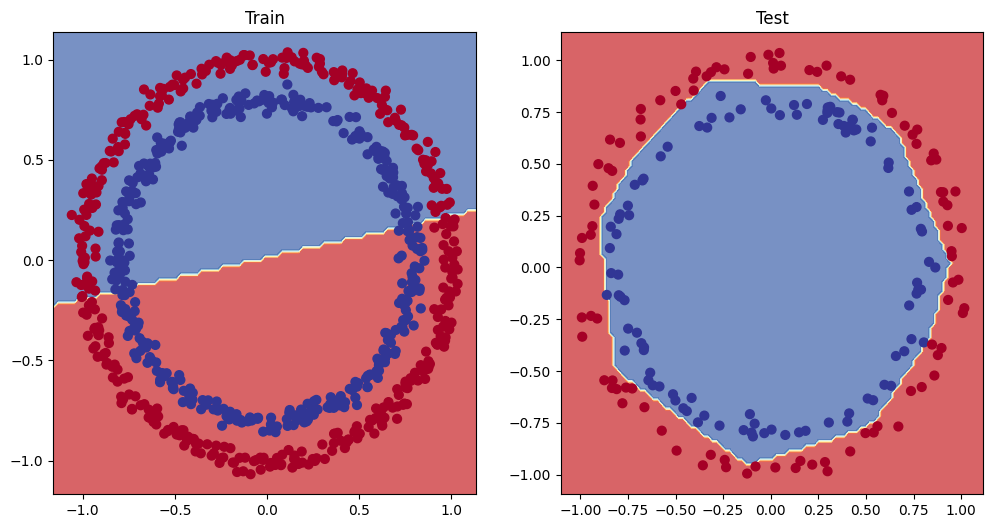

In [78]:
# Plot decision boundaries
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train) # model_1 = no non-linearity
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_3, X_test, y_test) # model_3 = has non-linearity

 # Putting it all together with a multi-class classification problem

   * Binary classification = one thing or another (cat vs. dog, spam vs. not spam, fraud or not fraud)
   * Multi-class classification = more than one thing or another (cat vs. dog vs. chicken)


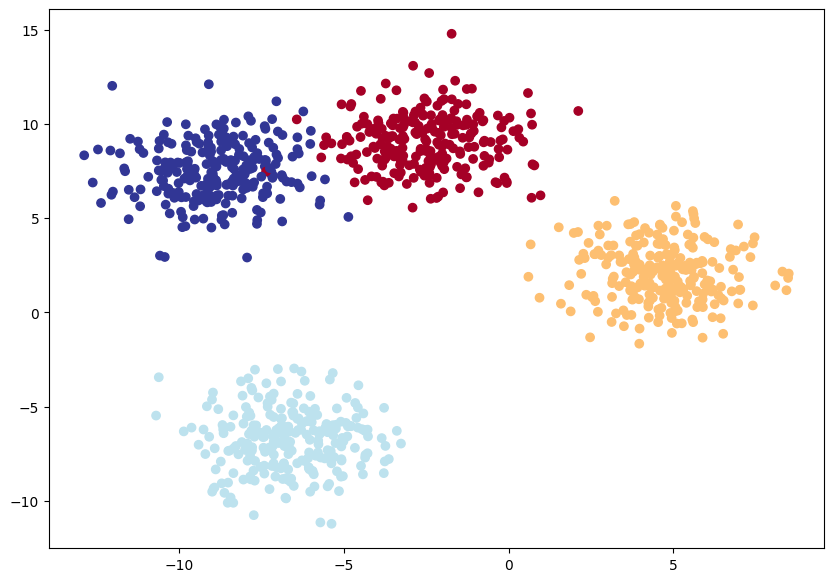

In [47]:
# @title
import torch
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Set the hyperparameters for data creation
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

# 1. Create multi-class data
X_blob, Y_blob = make_blobs(n_samples=1000,
                            n_features=NUM_FEATURES,
                            centers=NUM_CLASSES,
                            cluster_std=1.5, # give the clusters a little shake up
                            random_state=RANDOM_SEED)

# 2. Turn data into tensors
X_blob = torch.from_numpy(X_blob).type(torch.float)
Y_blob = torch.from_numpy(Y_blob).type(torch.LongTensor)

# 3. Split into train and test
X_blob_train, X_blob_test, Y_blob_train, Y_blob_test = train_test_split(X_blob,
                                                                        Y_blob,
                                                                        test_size=0.2,
                                                                        random_state=RANDOM_SEED)


# plot the data (visualize)

plt.figure(figsize=(10, 7 ))
plt.scatter(X_blob[:,0], X_blob[:,1],c= Y_blob,cmap=plt.cm.RdYlBu)


In [48]:
len(X_blob_train), len(X_blob_test), len(Y_blob_train), len(Y_blob_test)

(800, 200, 800, 200)

In [49]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [50]:
torch.unique(Y_blob_train)

tensor([0, 1, 2, 3])

In [51]:
X_blob_test.device

device(type='cpu')

In [52]:


# Build a multi-class classification model
class BlobModel(nn.Module):
  def __init__(self, input_features, output_features, hidden_units=8):
    """Initializes multi-class classification model.

    Args:
      input_features (int): Number of input features to the model
      output_features (int): Number of outputs features (number of output classes)
      hidden_units (int): Number of hidden units between layers, default 8

    Returns:

    Example:
    """
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features=input_features, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units, out_features=output_features)
    )

  def forward(self, x):
    return self.linear_layer_stack(x)

# Create an instance of BlobModel and send it to the target device
model_4 = BlobModel(input_features=2,
                    output_features=4,
                    hidden_units=8).to(device)

model_4



BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [53]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_4.parameters(),
                            lr=0.1)

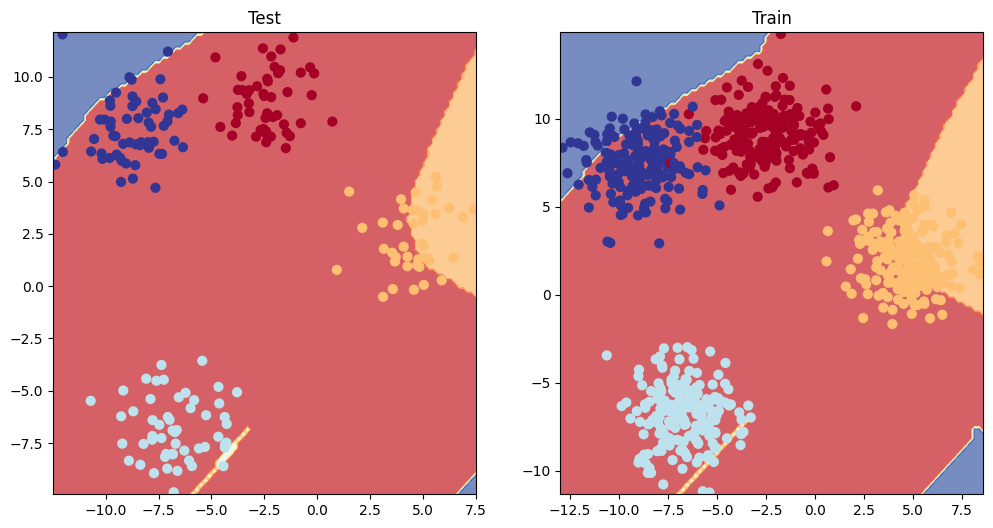

In [54]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Test")
plot_decision_boundary(model_4,X_blob_test,Y_blob_test)
plt.subplot(1,2,2)
plt.title("Train")
plot_decision_boundary(model_4,X_blob_train,Y_blob_train)

In [55]:
model_4.to(device)
X_blob_test.device , next(model_4.parameters()).device

(device(type='cpu'), device(type='cuda', index=0))

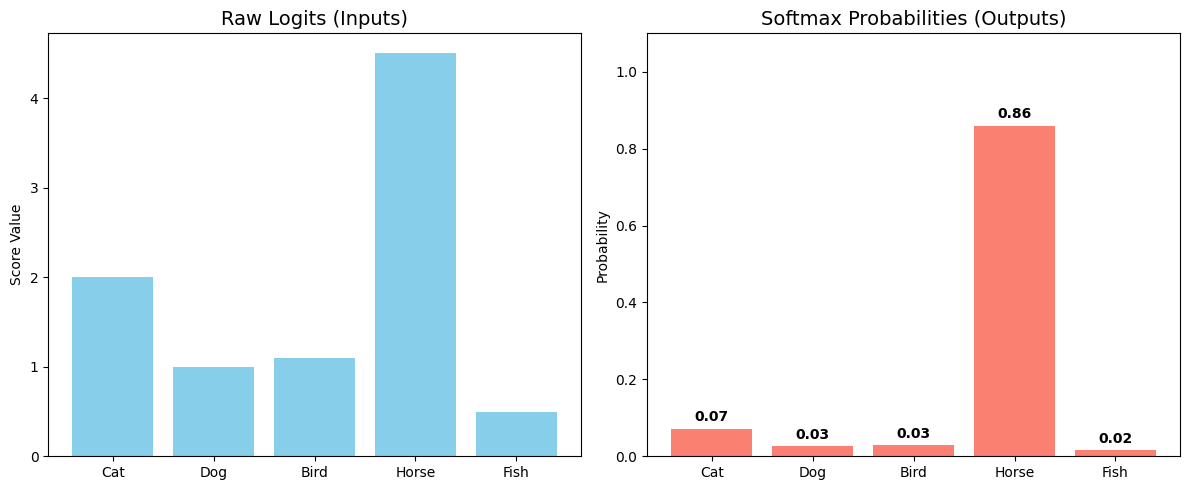

In [69]:
import numpy as np
import matplotlib.pyplot as plt

def softmax(logits):
    # Subtracting the max for numerical stability (prevents overflow)
    exps = np.exp(logits -100)
    return exps / np.sum(exps)

# 1. Define sample data
logits = np.array([2.0, 1.0, 1.1, 4.5, 0.5])
classes = ['Cat', 'Dog', 'Bird', 'Horse', 'Fish']
probabilities = softmax(logits)

# 2. Setup visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left Plot: Raw Scores (Logits)
ax1.bar(classes, logits, color='skyblue')
ax1.set_title('Raw Logits (Inputs)', fontsize=14)
ax1.set_ylabel('Score Value')

# Right Plot: Softmax Probabilities
ax2.bar(classes, probabilities, color='salmon')
ax2.set_title('Softmax Probabilities (Outputs)', fontsize=14)
ax2.set_ylabel('Probability')
ax2.set_ylim(0, 1.1) # Probabilities always sum to 1.0

# Add probability value labels on top of bars
for i, prob in enumerate(probabilities):
    ax2.text(i, prob + 0.02, f'{prob:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


In [57]:
model_4.eval()
with torch.inference_mode():
  y_logits = model_4(X_blob_test.to(device))

y_logits[:5]

tensor([[-0.7646, -0.7412, -1.5777, -1.1376],
        [-0.0973, -0.9431, -0.5963, -0.1371],
        [ 0.2528, -0.2379,  0.1882, -0.0066],
        [-0.4134, -0.5204, -0.9303, -0.6963],
        [-0.3118, -1.3736, -1.1991, -0.3834]], device='cuda:0')

In [58]:
y_pred_probs = torch.softmax(y_logits,dim=1)
y_pred_probs[:5] , y_logits[:5]

(tensor([[0.3169, 0.3244, 0.1405, 0.2182],
         [0.3336, 0.1432, 0.2026, 0.3206],
         [0.3011, 0.1843, 0.2823, 0.2323],
         [0.3078, 0.2766, 0.1836, 0.2320],
         [0.3719, 0.1286, 0.1532, 0.3463]], device='cuda:0'),
 tensor([[-0.7646, -0.7412, -1.5777, -1.1376],
         [-0.0973, -0.9431, -0.5963, -0.1371],
         [ 0.2528, -0.2379,  0.1882, -0.0066],
         [-0.4134, -0.5204, -0.9303, -0.6963],
         [-0.3118, -1.3736, -1.1991, -0.3834]], device='cuda:0'))

In [59]:
torch.argmax(y_pred_probs[0
                          ])

tensor(1, device='cuda:0')

In [60]:
# Model prediction to prediction lables
y_pred = torch.argmax(y_pred_probs,dim=1)
Y_pred_test = torch.argmax(y_logits,dim=1)

y_pred[:5], Y_blob_test[:5],torch.eq(y_pred[:10], Y_blob_test[:10].to(device))

(tensor([1, 0, 0, 0, 0], device='cuda:0'),
 tensor([1, 3, 2, 1, 0]),
 tensor([ True, False, False, False,  True, False, False,  True, False,  True],
        device='cuda:0'))

In [61]:
(y_pred == Y_pred_test).sum()

tensor(200, device='cuda:0')

In [62]:
len(y_pred)

200

In [63]:
(y_pred==Y_blob_test.to(device)).sum()

tensor(71, device='cuda:0')

In [64]:
len(Y_blob_train) ,len(Y_pred_test)

(800, 200)

In [65]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set number of epochs
epochs = 100

# Put data to the target device
X_blob_train, y_blob_train = X_blob_train.to(device), Y_blob_train.to(device)
X_blob_test, y_blob_test = X_blob_test.to(device), Y_blob_test.to(device)
model_4.to(device)
# Loop through data
for epoch in range(epochs):
  ### Training
  model_4.train()

  y_logits = model_4(X_blob_train)
  y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)

  loss = loss_fn(y_logits, y_blob_train)
  acc = accuracy_fn(y_true=y_blob_train,
                    y_pred=y_pred)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  ### Testing
  model_4.eval()
  with torch.inference_mode():
    test_logits = model_4(X_blob_test)
    test_preds = torch.softmax(test_logits, dim=1).argmax(dim=1)

    test_loss = loss_fn(test_logits, y_blob_test)
    test_acc = accuracy_fn(y_true=y_blob_test,
                           y_pred=test_preds)

  # Print out what's happenin'
  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.4f}, Acc: {acc:.2f}% | Test loss: {test_loss:.4f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 1.1588, Acc: 40.38% | Test loss: 1.0755, Test acc: 48.00%
Epoch: 10 | Loss: 0.6448, Acc: 96.75% | Test loss: 0.6607, Test acc: 97.50%
Epoch: 20 | Loss: 0.4254, Acc: 98.50% | Test loss: 0.4307, Test acc: 100.00%
Epoch: 30 | Loss: 0.2529, Acc: 99.12% | Test loss: 0.2451, Test acc: 99.50%
Epoch: 40 | Loss: 0.1123, Acc: 99.25% | Test loss: 0.1023, Test acc: 99.50%
Epoch: 50 | Loss: 0.0663, Acc: 99.25% | Test loss: 0.0585, Test acc: 99.50%
Epoch: 60 | Loss: 0.0507, Acc: 99.25% | Test loss: 0.0429, Test acc: 99.50%
Epoch: 70 | Loss: 0.0430, Acc: 99.25% | Test loss: 0.0349, Test acc: 99.50%
Epoch: 80 | Loss: 0.0384, Acc: 99.25% | Test loss: 0.0299, Test acc: 99.50%
Epoch: 90 | Loss: 0.0352, Acc: 99.25% | Test loss: 0.0266, Test acc: 99.50%


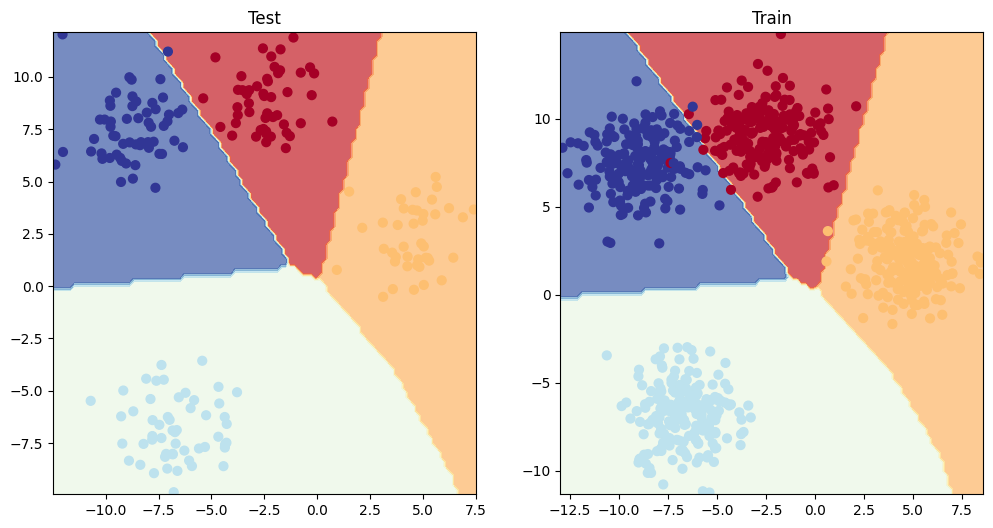

In [66]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Test")
plot_decision_boundary(model_4,X_blob_test,Y_blob_test)
plt.subplot(1,2,2)
plt.title("Train")
plot_decision_boundary(model_4,X_blob_train,Y_blob_train)

In [67]:

!pip install torchmetrics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 24.2 MB/s eta 0:00:00


In [70]:
from torchmetrics import Accuracy

torchmetric_accuracy = Accuracy(task='multiclass', num_classes=NUM_CLASSES).to(device)


torchmetric_accuracy(test_preds, y_blob_test)

tensor(0.9950, device='cuda:0')